# NG-DRI-EAF BAU steel NPV simulation

Run the Monte Carlo simulation for NG-DRI-EAF BAU steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "ng_dri_eaf_bau"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,656.126578,32.5,312.0,natural_gas,...,1.087321e+08,0.0,5.329491e+07,5.994538e+08,-1.494538e+08,-2.123486e+09,9.818147e+06,6.541652e+09,666.281722,-216.281722
1,1,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,657.615601,32.5,312.0,natural_gas,...,1.552383e+08,0.0,5.707677e+07,6.572947e+08,-2.072947e+08,-2.692866e+09,9.818147e+06,7.111032e+09,724.274343,-274.274343
2,2,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,653.745983,32.5,312.0,natural_gas,...,2.059305e+08,0.0,5.731841e+07,7.371392e+08,-2.871392e+08,-3.472921e+09,9.818147e+06,7.891087e+09,803.724662,-353.724662
3,3,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,654.262848,32.5,312.0,natural_gas,...,2.040725e+08,0.0,5.181148e+07,7.086407e+08,-2.586407e+08,-3.193635e+09,9.818147e+06,7.611801e+09,775.278778,-325.278778
4,4,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,659.448704,32.5,312.0,natural_gas,...,1.848976e+08,0.0,6.610478e+07,7.278072e+08,-2.778072e+08,-3.387000e+09,9.818147e+06,7.805167e+09,794.973460,-344.973460


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-3098.712366,765.610699,-315.610699
std,526.740123,53.649645,53.649645
min,-5066.683659,590.791394,-516.052922
5%,-3973.197083,676.857982,-404.678899
50%,-3098.545159,765.593669,-315.593669
95%,-2227.325104,854.678899,-226.857982
max,-1382.310660,966.052922,-140.791394


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


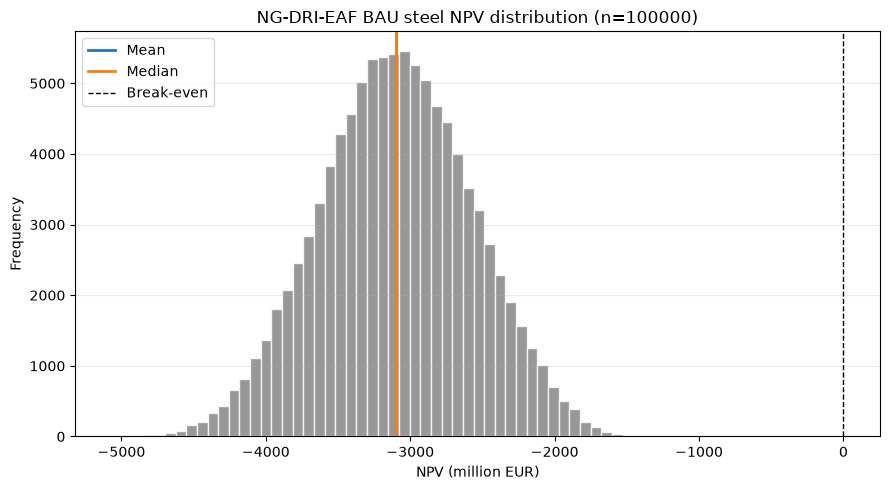

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-DRI-EAF BAU steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


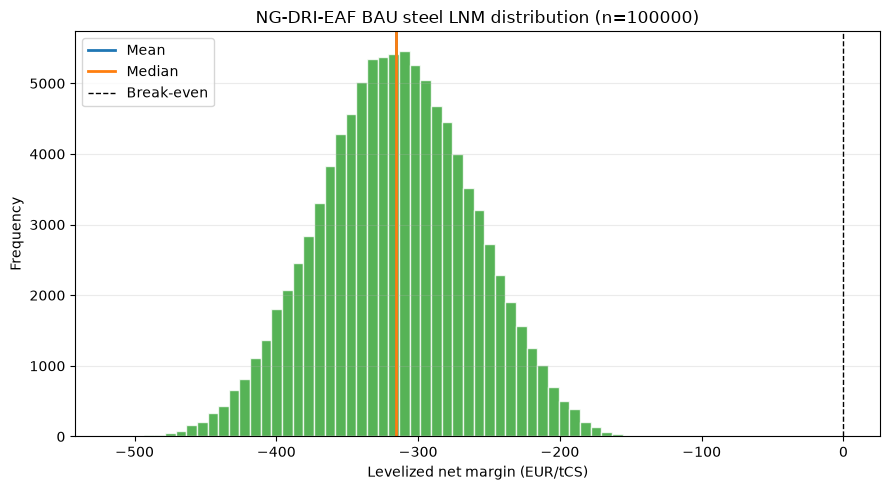

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"NG-DRI-EAF BAU steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


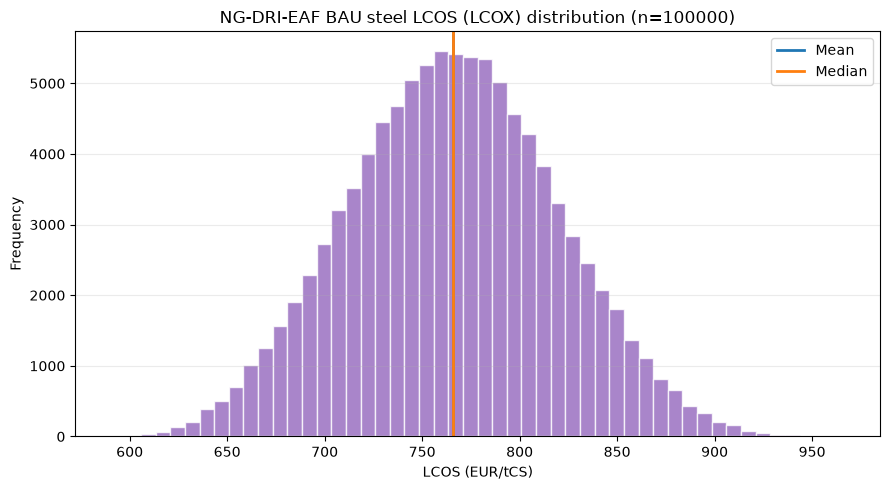

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"NG-DRI-EAF BAU steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             450.000000
annual_fixed_opex_eur           32.500000
annual_variable_opex_eur       312.000000
annual_fuel_cost_eur           102.511756
annual_electricity_cost_eur    194.684905
annual_emissions_cost_eur       57.030578
annual_net_cash_flow_eur      -248.727238
Name: Mean annual value, million EUR, dtype: float64